# Optional extra: News, Financial Crises, and the Geometry of Meaning

This notebook introduces **word embeddings** — dense vector representations of words
that capture semantic relationships through geometry. We demonstrate the classic
analogy **king - man + woman = queen** using pre-trained GloVe vectors, then explore
what this means for financial text analysis.

**Why this matters for our project:** The draft paper uses LLM embeddings to extract
crisis-relevant signals from historical newspaper text. Before working with modern
contextual embeddings, we need the foundational intuition: words can be points in
a vector space, and directions in that space encode meaning.

---
## What Are Word Embeddings?

### The Problem with Traditional Representations

In traditional NLP, words are represented as **one-hot vectors** — a vocabulary of
10,000 words means each word is a 10,000-dimensional vector with a single 1 and the
rest 0s. This has a fatal flaw: every pair of words is equally distant. "king" is no
more similar to "queen" than it is to "banana."

### The Distributional Hypothesis

The key insight comes from linguist J.R. Firth (1957):

> *"You shall know a word by the company it keeps."*

Words that appear in similar contexts tend to have similar meanings. "King" and "queen"
appear near words like "throne", "crown", "royal" — so they should have similar
representations.

### Word2Vec: The Breakthrough (Mikolov et al., 2013)

**Word2Vec** was the paper that launched the modern embeddings revolution. Mikolov et al.
at Google trained a shallow neural network to predict words from their context (or vice
versa), and discovered that the learned vectors exhibited remarkable algebraic structure:

$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

This single example — that vector arithmetic can solve analogies — transformed how the
field thinks about word meaning.

### GloVe: A Refinement (Pennington et al., 2014)

**GloVe** (Global Vectors for Word Representation), from Stanford, achieves similar
results via a different method: factorizing the word-word co-occurrence matrix. The
resulting vectors are practically interchangeable with Word2Vec for analogy tasks.
We use GloVe vectors here because the files are easy to work with (plain text,
no special library needed).

### The Road to Modern LLMs

The progression from static to contextual embeddings is:

| Year | Model | Key Innovation |
|------|-------|----------------|
| 2013 | **Word2Vec** | Words as vectors; analogy via arithmetic |
| 2014 | **GloVe** | Co-occurrence matrix factorization |
| 2018 | **ELMo** | Context-dependent word vectors (biLSTM) |
| 2018 | **BERT** | Transformer-based contextual embeddings |
| 2018+ | **GPT family** | Autoregressive transformers at scale |

The critical limitation of Word2Vec/GloVe — one vector per word regardless of
context — is exactly what BERT and GPT overcome. We'll see this concretely below.

---
## Load the Embeddings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from settings import config

DATA_DIR = Path(config("DATA_DIR"))

# Load pre-computed GloVe embeddings (filtered to common words + finance vocabulary)
embeddings_df = pd.read_parquet(DATA_DIR / "glove_embeddings.parquet")
print(f"Vocabulary size: {len(embeddings_df):,} words")
print(f"Embedding dimensions: {embeddings_df.shape[1] - 1}")

Vocabulary size: 5,018 words
Embedding dimensions: 50


In [2]:
# Build word -> vector lookup
dim_cols = [c for c in embeddings_df.columns if c.startswith("d")]

word_to_vec = {}
for _, row in embeddings_df.iterrows():
    word_to_vec[row["word"]] = row[dim_cols].values.astype(np.float64)

print(f"Loaded {len(word_to_vec):,} word vectors")
print(f"Example — vector for 'king' (first 10 dims): {word_to_vec['king'][:10]}")

Loaded 5,018 word vectors
Example — vector for 'king' (first 10 dims): [ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012 ]


In [3]:
embeddings_df.head(10)

,word,d0,d1,d2,d3,d4,d5,d6,d7,d8,...,d40,d41,d42,d43,d44,d45,d46,d47,d48,d49
0,the,0.418000,0.249680,-0.41242,0.121700,0.345270,-0.044457,-0.49688,-0.178620,-0.000660,...,-0.298710,-0.157490,-0.347580,-0.045637,-0.442510,0.187850,0.002785,-0.184110,-0.115140,-0.785810
1,",",0.013441,0.236820,-0.16899,0.409510,0.638120,0.477090,-0.42852,-0.556410,-0.364000,...,-0.080262,0.630030,0.321110,-0.467650,0.227860,0.360340,-0.378180,-0.566570,0.044691,0.303920
2,.,0.151640,0.301770,-0.16763,0.176840,0.317190,0.339730,-0.43478,-0.310860,-0.449990,...,-0.000064,0.068987,0.087939,-0.102850,-0.139310,0.223140,-0.080803,-0.356520,0.016413,0.102160
3,of,0.708530,0.570880,-0.47160,0.180480,0.544490,0.726030,0.18157,-0.523930,0.103810,...,-0.347270,0.284830,0.075693,-0.062178,-0.389880,0.229020,-0.216170,-0.225620,-0.093918,-0.803750
4,to,0.680470,-0.039263,0.30186,-0.177920,0.429620,0.032246,-0.41376,0.132280,-0.298470,...,-0.094375,0.018324,0.210480,-0.030880,-0.197220,0.082279,-0.094340,-0.073297,-0.064699,-0.260440
5,and,0.268180,0.143460,-0.27877,0.016257,0.113840,0.699230,-0.51332,-0.473680,-0.330750,...,-0.069043,0.368850,0.251680,-0.245170,0.253810,0.136700,-0.311780,-0.632100,-0.250280,-0.380970
6,in,0.330420,0.249950,-0.60874,0.109230,0.036372,0.151000,-0.55083,-0.074239,-0.092307,...,-0.486090,-0.008027,0.031184,-0.365760,-0.426990,0.421640,-0.116660,-0.507030,-0.027273,-0.532850
7,a,0.217050,0.465150,-0.46757,0.100820,1.013500,0.748450,-0.53104,-0.262560,0.168120,...,0.138130,0.369730,-0.642890,0.024142,-0.039315,-0.260370,0.120170,-0.043782,0.410130,0.179600
8,"""",0.257690,0.456290,-0.76974,-0.376790,0.592720,-0.063527,0.20545,-0.573850,-0.290090,...,0.030498,-0.395430,-0.385150,-1.000200,0.087599,-0.310090,-0.346770,-0.314380,0.750040,0.970650
9,'s,0.237270,0.404780,-0.20547,0.588050,0.655330,0.328670,-0.81964,-0.232360,0.274280,...,-0.123420,0.659610,-0.518020,-0.829950,-0.082739,0.281550,-0.423000,-0.273780,-0.007901,-0.030231


---
## Exploring Word Similarity

The most basic operation on word vectors is **cosine similarity**: how closely two
vectors point in the same direction, regardless of magnitude. Values range from -1
(opposite) to +1 (identical direction).

In [4]:
def cosine_similarity(a, b):
    """Cosine similarity between two vectors."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


def most_similar(word, topn=10):
    """Find the topn most similar words by cosine similarity."""
    vec = word_to_vec[word]
    sims = {w: cosine_similarity(vec, v) for w, v in word_to_vec.items() if w != word}
    ranked = sorted(sims.items(), key=lambda x: x[1], reverse=True)[:topn]
    return pd.DataFrame(ranked, columns=["word", "similarity"])

In [5]:
# What's most similar to "king"?
most_similar("king")

,word,similarity
0,prince,0.823618
1,queen,0.783904
2,ii,0.774623
3,emperor,0.773625
4,son,0.766719
5,uncle,0.762715
6,kingdom,0.754216
7,brother,0.749241
8,lord,0.738872
9,father,0.733572


In [6]:
# What's most similar to "crisis"?
most_similar("crisis")

,word,similarity
0,economic,0.828236
1,fears,0.819536
2,crises,0.815953
3,wake,0.810680
4,continuing,0.800332
5,amid,0.797913
6,concern,0.795947
7,collapse,0.793501
8,ongoing,0.789457
9,situation,0.788831


In [7]:
# What's most similar to "bank"?
# Note: GloVe assigns ONE vector per word — "bank" (financial institution)
# and "bank" (river bank) are merged into the same representation.
most_similar("bank")

,word,similarity
0,banks,0.869863
1,securities,0.799681
2,banking,0.796516
3,investment,0.784971
4,exchange,0.780883
5,financial,0.767027
6,credit,0.764915
7,capital,0.738071
8,currency,0.736360
9,investments,0.734035


---
## The Classic Analogy: king - man + woman = ?

This is the most famous result in word embeddings. The idea is simple:

1. Compute the **difference** `king - man` — this captures the concept of "royalty"
   stripped of gender.
2. **Add** that difference to `woman` — this applies the "royalty" concept to the
   female gender.
3. Find the **nearest word** to the resulting vector.

If the embedding space has learned the right structure, the answer should be **queen**.

In [8]:
def analogy(a, b, c, topn=5):
    """Solve: a is to b as c is to ?

    Computes: vec(b) - vec(a) + vec(c) and finds the nearest words.

    Example: analogy("man", "king", "woman") asks
             "man is to king as woman is to ___?"
    """
    target = word_to_vec[b] - word_to_vec[a] + word_to_vec[c]
    exclude = {a, b, c}
    sims = {
        w: cosine_similarity(target, v)
        for w, v in word_to_vec.items()
        if w not in exclude
    }
    ranked = sorted(sims.items(), key=lambda x: x[1], reverse=True)[:topn]
    return pd.DataFrame(ranked, columns=["word", "similarity"])

In [9]:
# THE classic example: man is to king as woman is to ___?
analogy("man", "king", "woman")

,word,similarity
0,queen,0.860958
1,daughter,0.768451
2,prince,0.764070
3,princess,0.751273
4,elizabeth,0.750649


In [10]:
# More analogies
analogy_examples = [
    ("man", "king", "woman", "Gender → Royalty"),
    ("man", "brother", "woman", "Gender → Sibling"),
    ("man", "husband", "woman", "Gender → Spouse"),
    ("man", "father", "woman", "Gender → Parent"),
    ("france", "paris", "germany", "Country → Capital"),
    ("france", "paris", "japan", "Country → Capital"),
    ("slow", "slower", "fast", "Comparative"),
    ("good", "better", "bad", "Comparative"),
]

results = []
for a, b, c, label in analogy_examples:
    top = analogy(a, b, c, topn=1)
    results.append({
        "Analogy": f"{a} : {b} :: {c} : ?",
        "Top Answer": top.iloc[0]["word"],
        "Similarity": round(top.iloc[0]["similarity"], 4),
        "Category": label,
    })

pd.DataFrame(results)

,Analogy,Top Answer,Similarity,Category
0,man : king :: woman : ?,queen,0.8610,Gender → Royalty
1,man : brother :: woman : ?,daughter,0.9374,Gender → Sibling
2,man : husband :: woman : ?,wife,0.9150,Gender → Spouse
3,man : father :: woman : ?,mother,0.9371,Gender → Parent
4,france : paris :: germany : ?,berlin,0.9181,Country → Capital
5,france : paris :: japan : ?,tokyo,0.9190,Country → Capital
6,slow : slower :: fast : ?,faster,0.8346,Comparative
7,good : better :: bad : ?,worse,0.8973,Comparative


### Discussion: man : brother :: woman : ?

The analogy table above likely did **not** return "sister" for this one.
Look at the top-10 results below — why might the arithmetic fail here
when it works for king/queen?

In [11]:
analogy("man", "brother", "woman", topn=10)

,word,similarity
0,daughter,0.937444
1,wife,0.913468
2,mother,0.899247
3,father,0.893666
4,niece,0.871679
5,son,0.868607
6,husband,0.859746
7,sister,0.855019
8,married,0.853591
9,daughters,0.825262


---
## Why Does This Work? The Parallelogram Structure

The analogy works because the embedding space encodes semantic relationships as
**consistent directions**. The vector from "man" to "king" (the "royalty" direction)
is approximately parallel to the vector from "woman" to "queen."

In other words, the four words form a **parallelogram** in the high-dimensional space:

```
    man ---------> king
     |               |
     | (gender)       | (gender)
     |               |
     v               v
   woman --------> queen
         (royalty)
```

We can verify this by checking that the "gender direction" is consistent across
the royalty pair:

In [12]:
# The "royalty" direction
diff_royalty_male = word_to_vec["king"] - word_to_vec["man"]
diff_royalty_female = word_to_vec["queen"] - word_to_vec["woman"]

# The "gender" direction
diff_gender_common = word_to_vec["woman"] - word_to_vec["man"]
diff_gender_royal = word_to_vec["queen"] - word_to_vec["king"]

print("Are the 'royalty' directions consistent across genders?")
print(f"  cos(king-man, queen-woman) = {cosine_similarity(diff_royalty_male, diff_royalty_female):.4f}")
print()
print("Are the 'gender' directions consistent across royalty?")
print(f"  cos(woman-man, queen-king) = {cosine_similarity(diff_gender_common, diff_gender_royal):.4f}")

Are the 'royalty' directions consistent across genders?
  cos(king-man, queen-woman) = 0.8397

Are the 'gender' directions consistent across royalty?
  cos(woman-man, queen-king) = 0.5970


---
## Visualizing the Embedding Space

### The Analogy Parallelogram in 2D

We project the words `king`, `queen`, `man`, `woman` (plus a few related words) into
2D using PCA. The parallelogram structure should be visible even after this drastic
dimensionality reduction from 50 → 2.

In [13]:
from sklearn.decomposition import PCA
import plotly.graph_objects as go

analogy_words = ["king", "queen", "man", "woman", "prince", "princess", "boy", "girl"]
vecs = np.array([word_to_vec[w] for w in analogy_words])

pca = PCA(n_components=2)
coords = pca.fit_transform(vecs)

fig = go.Figure()

# Plot all words
fig.add_trace(go.Scatter(
    x=coords[:, 0], y=coords[:, 1],
    mode="markers+text",
    text=analogy_words,
    textposition="top center",
    marker=dict(size=12, color="#636EFA"),
    textfont=dict(size=13),
    showlegend=False,
))

# Draw arrows for the "royalty" direction (man→king, woman→queen)
for i_from, i_to, color, name in [
    (2, 0, "#EF553B", "royalty"),  # man → king
    (3, 1, "#EF553B", None),       # woman → queen
    (2, 3, "#00CC96", "gender"),   # man → woman
    (0, 1, "#00CC96", None),       # king → queen
]:
    fig.add_annotation(
        x=coords[i_to, 0], y=coords[i_to, 1],
        ax=coords[i_from, 0], ay=coords[i_from, 1],
        xref="x", yref="y", axref="x", ayref="y",
        showarrow=True,
        arrowhead=2, arrowsize=1.5, arrowwidth=2,
        arrowcolor=color, opacity=0.6,
    )

# Manual legend
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
    line=dict(color="#EF553B", width=2), name="royalty direction"))
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
    line=dict(color="#00CC96", width=2), name="gender direction"))

fig.update_layout(
    title="Word Embedding Parallelogram (PCA Projection to 2D)",
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
    height=550,
    template="plotly_white",
)
fig.show()

### Cosine Similarity Heatmap

A heatmap of pairwise similarities reveals the semantic clustering structure
at a glance. Words within the same category (royalty, family, finance) should
show higher mutual similarity.

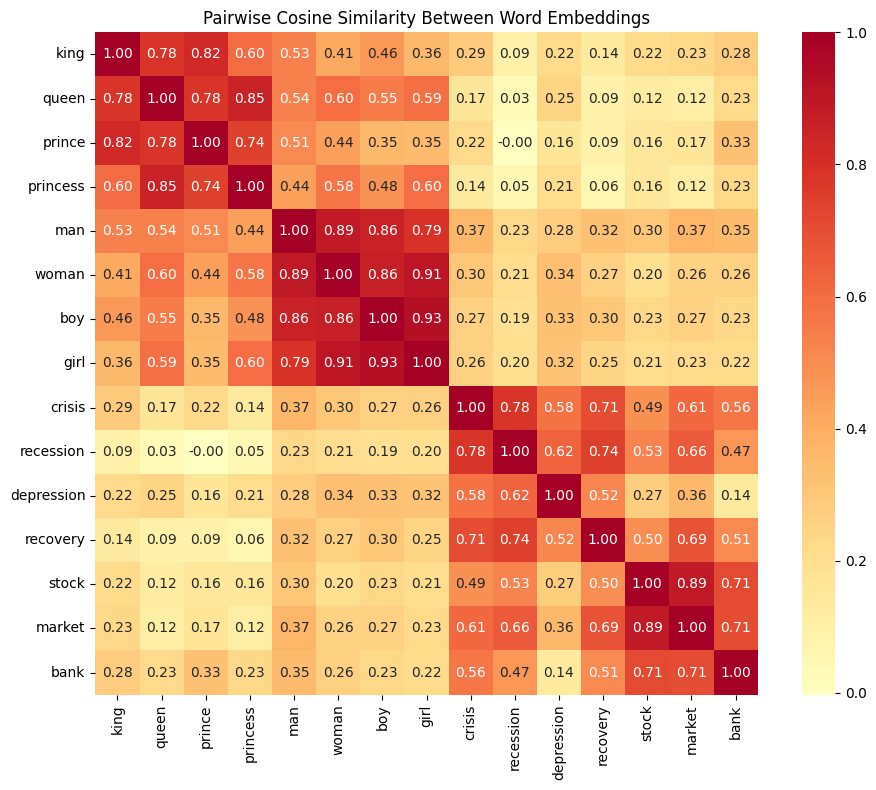

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_words = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "crisis", "recession", "depression", "recovery",
    "stock", "market", "bank",
]

heatmap_vecs = np.array([word_to_vec[w] for w in heatmap_words])

# Compute pairwise cosine similarity matrix
norms = np.linalg.norm(heatmap_vecs, axis=1, keepdims=True)
sim_matrix = (heatmap_vecs @ heatmap_vecs.T) / (norms @ norms.T)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=heatmap_words,
    yticklabels=heatmap_words,
    cmap="RdYlBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    ax=ax,
)
ax.set_title("Pairwise Cosine Similarity Between Word Embeddings")
plt.tight_layout()
plt.show()

### Financial Word Clusters

How well do GloVe embeddings organize financial and economic concepts?

In [15]:
finance_words = [
    "crisis", "recession", "depression", "panic", "crash", "bust", "collapse",
    "growth", "boom", "recovery", "expansion",
    "bank", "stock", "market", "bond", "debt", "credit", "loan", "mortgage",
    "inflation", "deflation", "unemployment", "interest",
]

finance_vecs = np.array([word_to_vec[w] for w in finance_words])

pca_fin = PCA(n_components=2)
fin_coords = pca_fin.fit_transform(finance_vecs)

# Color by rough category
colors = []
for w in finance_words:
    if w in {"crisis", "recession", "depression", "panic", "crash", "bust", "collapse"}:
        colors.append("Downturn")
    elif w in {"growth", "boom", "recovery", "expansion"}:
        colors.append("Upturn")
    elif w in {"inflation", "deflation", "unemployment", "interest"}:
        colors.append("Macro indicator")
    else:
        colors.append("Financial instrument")

import plotly.express as px

fin_df = pd.DataFrame({
    "word": finance_words,
    "PC1": fin_coords[:, 0],
    "PC2": fin_coords[:, 1],
    "category": colors,
})

fig = px.scatter(
    fin_df, x="PC1", y="PC2", text="word", color="category",
    title="Financial Terms in Embedding Space (PCA Projection)",
    labels={
        "PC1": f"PC1 ({pca_fin.explained_variance_ratio_[0]:.1%} variance)",
        "PC2": f"PC2 ({pca_fin.explained_variance_ratio_[1]:.1%} variance)",
    },
    color_discrete_sequence=["#EF553B", "#636EFA", "#00CC96", "#AB63FA"],
)
fig.update_traces(textposition="top center", marker=dict(size=10))
fig.update_layout(height=550, template="plotly_white")
fig.show()

---
## Financial Analogies

Do analogies work for financial concepts the way they do for gender and royalty?

In [16]:
finance_analogies = [
    ("recession", "unemployment", "growth", "Recession:Unemployment :: Growth:?"),
    ("stock", "market", "bond", "Stock:Market :: Bond:?"),
    ("inflation", "prices", "deflation", "Inflation:Prices :: Deflation:?"),
    ("bank", "loan", "company", "Bank:Loan :: Company:?"),
]

results = []
for a, b, c, label in finance_analogies:
    top = analogy(a, b, c, topn=3)
    results.append({
        "Analogy": label,
        "Top 3": ", ".join(top["word"].tolist()),
    })

pd.DataFrame(results)

,Analogy,Top 3
0,Recession:Unemployment :: Growth:?,"increase, increased, employment"
1,Stock:Market :: Bond:?,"rates, interest, rate"
2,Inflation:Prices :: Deflation:?,"markets, market, stocks"
3,Bank:Loan :: Company:?,"purchase, contract, acquisition"


Financial analogies are **noisier** than the king/queen example. This makes sense:
financial concepts are more context-dependent and less cleanly decomposable into
orthogonal semantic dimensions. A "recession" involves unemployment, falling output,
credit contraction, and policy responses all at once — there is no single clean
"direction" the way there is for gender.

This is one motivation for moving to **contextual embeddings** (BERT, GPT): the
meaning of "bank" in *"the central bank raised rates"* is very different from
*"he sat on the river bank"*, but GloVe assigns them the **same vector**.

---
## From Words to Documents: Can Embedding Arithmetic Scale Up?

The financial word analogies above were noisy — single words are too coarse to
capture the complexity of a banking crisis. But what if we embed **entire
newspaper articles** instead of individual words?

Modern contextual embedding models (the descendants of Word2Vec discussed above)
can produce a single vector for a full document. If the embedding space encodes
crisis-relevant structure, then the same arithmetic should work at the document
level:

$$\vec{\text{crisis article}}_A - \vec{\text{tranquil article}}_A + \vec{\text{tranquil article}}_B \approx \vec{\text{crisis article}}_B$$

### The Document-Level Parallelogram

The logic is identical to king − man + woman = queen, but with documents:

```
    tranquil_A ---------> crisis_A
         |                    |
         | (context shift)    | (context shift)
         |                    |
         v                    v
    tranquil_B ---------> crisis_B  (← predicted)
             (crisis direction)
```

If the "crisis direction" (the vector difference between a crisis article and its
paired tranquil article) is consistent across different time periods or countries,
then the arithmetic will land near the correct crisis article.

We test this with two hand-picked quadruplets from our curated corpus of historical
newspaper articles.

In [17]:
from sklearn.metrics.pairwise import cosine_similarity as pairwise_cosine_similarity

import embedding_analysis as ea
from build_manual_article_catalog import load_manual_article_catalog

PRIMARY_MODEL = "openai/text-embedding-3-large"

catalog = load_manual_article_catalog()
doc_embeddings = ea.load_embeddings(PRIMARY_MODEL)
doc_df = ea.merge_embeddings_with_catalog(doc_embeddings, catalog)
print(f"Loaded {len(doc_df)} articles with {PRIMARY_MODEL} embeddings")

Loaded 1078 articles with openai/text-embedding-3-large embeddings


In [18]:
from IPython.display import display, HTML

SCANS_DIR = Path(config("BASE_DIR")) / "assets" / "scans"


def show_scans(scans, width=300):
    """Display newspaper scan images side by side.

    Parameters
    ----------
    scans : list of (filename, caption) tuples
    width : int, pixel width per image
    """
    items = []
    for filename, caption in scans:
        path = SCANS_DIR / filename
        items.append(
            f'<div style="text-align:center; margin:0 10px">'
            f'<img src="{path}" width="{width}"><br>'
            f'<em style="font-size:0.9em">{caption}</em></div>'
        )
    html = f'<div style="display:flex; flex-wrap:wrap; align-items:flex-start; gap:10px">{"".join(items)}</div>'
    display(HTML(html))

In [19]:
ANALOGY_QUADRUPLETS = {
    "US Time Period\n(1870s → 1970s)": {
        "description": "crisis₁₈₇₃ − tranquil₁₈₇₁ + tranquil₁₉₇₂ ≈ crisis₁₉₇₄",
        "A": "12_1873-09-19_p1_sn83016025_00279525358_1873091901_0459",
        "A_label": "US 1873 crisis — Jay Cooke & Co. suspension",
        "B": "15_1871-11-03_p3_sn83045160_00200293022_1871110301_0506",
        "B_label": "US 1871 tranquil — Memphis routine finance",
        "C": "nw_1972_dow_jones_1000_nov",
        "C_label": "US 1972 tranquil — Dow Jones above 1,000",
        "D": "nw_1974_franklin_national_bank_failure",
        "D_label": "US 1974 crisis — Franklin National Bank failure",
        "alt_targets": {
            "Two Bank Failures": "nw_1974_two_bank_failures_deposit_insurance",
        },
    },
    "US vs France\n(1890 vs 1889)": {
        "description": "us_crisis₁₈₉₀ − us_tranquil₁₈₈₈ + france_tranquil₁₈₈₇ ≈ france_crisis₁₈₈₉",
        "A": "14_1890-11-12_p1_sn85034438_00175048303_1890111201_0301",
        "A_label": "US 1890 crisis — Wall Street panic (Richmond Times)",
        "B": "nw_1888_treasury_surplus_estimate_fy1889",
        "B_label": "US 1888 tranquil — Treasury Secretary surplus estimate",
        "C": "2_1887-12-24_p2_sn82014381_00175036544_1887122401_0428",
        "C_label": "France 1887 tranquil — Bank of France silver coin handling",
        "D": "nw_1889_metaux_dissolution_parliamentary_inquiry",
        "D_label": "France 1889 crisis — Comptoir d'Escompte reconstruction",
        "alt_targets": {
            "Rouvier appeal": "nw_1889_rouvier_appeal_bank_of_france",
            "Copper ring collapse": "nw_1889_copper_ring_collapse_london",
        },
    },
}

# Show article summary
rows = []
for analogy_name, q in ANALOGY_QUADRUPLETS.items():
    for role, label_key in [("King (crisis A)", "A"), ("Man (tranquil A)", "B"),
                            ("Woman (tranquil B)", "C"), ("Queen (crisis B)", "D")]:
        aid = q[label_key]
        match = doc_df[doc_df["article_id"] == aid]
        headline = match.iloc[0]["headline"][:80] if len(match) > 0 else "(not found)"
        rows.append({"Analogy": analogy_name, "Role": role, "Label": q[f"{label_key}_label"],
                      "Headline": headline})

pd.DataFrame(rows)

,Analogy,Role,Label,Headline
0,US Time Period\n(1870s → 1970s),King (crisis A),US 1873 crisis — Jay Cooke & Co. suspension,THE STOCK PANIC. FAILURE OF JAY COOKE & CO. A ...
1,US Time Period\n(1870s → 1970s),Man (tranquil A),US 1871 tranquil — Memphis routine finance,FINANCE AND TRADE.
2,US Time Period\n(1870s → 1970s),Woman (tranquil B),"US 1972 tranquil — Dow Jones above 1,000","Dow Jones Industrial Average Closes Above 1,00..."
3,US Time Period\n(1870s → 1970s),Queen (crisis B),US 1974 crisis — Franklin National Bank failure,Biggest bank failure in nation's history doesn...
4,US vs France\n(1890 vs 1889),King (crisis A),US 1890 crisis — Wall Street panic (Richmond T...,TERRIFIC EXCITEMENT. THE STREET CONVULSED WITH...
5,US vs France\n(1890 vs 1889),Man (tranquil A),US 1888 tranquil — Treasury Secretary surplus ...,Acting Secretary Thompson Estimates Treasury S...
6,US vs France\n(1890 vs 1889),Woman (tranquil B),France 1887 tranquil — Bank of France silver c...,Bank of France — Coin Handling and Anti-Counte...
7,US vs France\n(1890 vs 1889),Queen (crisis B),France 1889 crisis — Comptoir d'Escompte recon...,Societe des Metaux Shareholders Seek Dissoluti...


In [20]:
def get_article_vec(article_id, df=doc_df):
    """Return the embedding vector for a given article_id."""
    match = df[df["article_id"] == article_id]
    if len(match) == 0:
        raise ValueError(f"Article not found: {article_id}")
    return match.iloc[0]["embedding"]


def document_analogy(a_id, b_id, c_id, df, topn=10):
    """Solve: crisis_A − tranquil_A + tranquil_B ≈ ?

    Returns a DataFrame of the topn nearest articles to the predicted vector.
    """
    target = get_article_vec(a_id, df) - get_article_vec(b_id, df) + get_article_vec(c_id, df)
    exclude = {a_id, b_id, c_id}

    candidates = df[~df["article_id"].isin(exclude)].copy()
    X_cand = ea.embedding_matrix(candidates)
    sims = pairwise_cosine_similarity(target.reshape(1, -1), X_cand).flatten()

    candidates = candidates.copy()
    candidates["similarity"] = sims
    candidates = candidates.nlargest(topn, "similarity")

    result = candidates[["article_id", "similarity", "headline", "article_type",
                         "bvx_country", "bvx_year"]].reset_index(drop=True)
    result.index = result.index + 1
    result.index.name = "rank"
    return result


def document_parallelogram_check(a_id, b_id, c_id, d_id, df):
    """Check parallelogram consistency for a document quadruplet.

    Returns cosine similarities between parallel edge pairs,
    mirroring the word-level check for king/queen above.
    """
    vec_a = get_article_vec(a_id, df)  # crisis_A  (king)
    vec_b = get_article_vec(b_id, df)  # tranquil_A (man)
    vec_c = get_article_vec(c_id, df)  # tranquil_B (woman)
    vec_d = get_article_vec(d_id, df)  # crisis_B  (queen)

    # Crisis direction: (crisis_A − tranquil_A) vs (crisis_B − tranquil_B)
    crisis_dir_a = vec_a - vec_b
    crisis_dir_b = vec_d - vec_c

    # Context shift: (tranquil_B − tranquil_A) vs (crisis_B − crisis_A)
    shift_tranquil = vec_c - vec_b
    shift_crisis = vec_d - vec_a

    return {
        "crisis_direction": cosine_similarity(crisis_dir_a, crisis_dir_b),
        "context_shift": cosine_similarity(shift_tranquil, shift_crisis),
    }


def find_article_rank(a_id, b_id, c_id, target_id, df):
    """Find the rank (1-indexed) of target_id in the analogy results."""
    target = get_article_vec(a_id, df) - get_article_vec(b_id, df) + get_article_vec(c_id, df)
    exclude = {a_id, b_id, c_id}
    candidates = df[~df["article_id"].isin(exclude)].copy()
    X_cand = ea.embedding_matrix(candidates)
    sims = pairwise_cosine_similarity(target.reshape(1, -1), X_cand).flatten()
    candidates = candidates.copy()
    candidates["similarity"] = sims
    candidates = candidates.sort_values("similarity", ascending=False).reset_index(drop=True)
    match = candidates[candidates["article_id"] == target_id]
    if len(match) == 0:
        return None, None, len(candidates)
    rank = match.index[0] + 1
    sim = match.iloc[0]["similarity"]
    return rank, sim, len(candidates)

### Analogy 1: Crisis Across Time (U.S. 1873 → U.S. 1974)

Can the "crisis direction" from the 1870s predict the crisis article from the
1970s — a full century later?

- **King**: Jay Cooke & Co. suspension, September 1873 (Panic of 1873)
- **Man**: Memphis routine finance report, November 1871
- **Woman**: Dow Jones closes above 1,000, November 1972
- **Predicted Queen**: crisis₁₈₇₃ − tranquil₁₈₇₁ + tranquil₁₉₇₂ ≈ ?
- **Expected**: Franklin National Bank failure, October 1974

The original newspaper scans for the two 19th-century articles in this
analogy show the contrast between crisis and tranquil financial reporting:

In [21]:
show_scans([
    ("US_1873_crisis.png", "U.S. 1873 crisis: Jay Cooke & Co. suspension"),
    ("US_1871_tranquil.png", "U.S. 1871 tranquil: Memphis routine finance"),
])

In [22]:
q1 = ANALOGY_QUADRUPLETS["US Time Period\n(1870s → 1970s)"]
document_analogy(q1["A"], q1["B"], q1["C"], doc_df, topn=10)

,article_id,similarity,headline,article_type,bvx_country,bvx_year
rank,,,,,,
1,14_1873-09-21_p1_sn83045160_00200293083_187309...,0.483706,THE MONEY PANIC. Continuation Of the Excitemen...,crisis,U.S.,1873.0
2,nw_1907_morgan_relief_trust_company_runs,0.460031,Calmer Tone After Morgan-Rockefeller Relief Me...,crisis,U.S.,1907.0
3,51_1907-10-22_p1_sn84020616_00280774212_190710...,0.437460,IT COULD NOT SECURE CURRENCY FAST ENOUGH. Knic...,crisis,U.S.,1907.0
4,3_1907-11-02_p1_sn85058179_00237285438_1907110...,0.433266,FINANCIAL STORM IN NEW YORK CITY. The Knickerb...,crisis,U.S.,1907.0
5,25_1884-05-07_p1_sn83030214_00175038012_188405...,0.432869,DETAILS OF THE TWO FAILURES. THE BANK PROBABLY...,crisis,U.S.,1884.0
6,nw_1884_metropolitan_bank_panic_spreading,0.432792,Metropolitan Bank Suspends Payment Amid Spread...,crisis,U.S.,1884.0
7,3_1914-07-31_p1_sn86086633_00296023541_1914073...,0.429357,TRANSACTIONS IN SECURITIES COME TO HALT. New Y...,crisis,U.S.,1914.0
8,48_1937-10-10_p2_sn83045462_00280602036_193710...,0.429224,"Wall Street erases $10,000,000,000 in stock va...",crisis,U.S.,1937.0
9,14_1890-11-12_p1_sn85034438_00175048303_189011...,0.423268,TERRIFIC EXCITEMENT. THE STREET CONVULSED WITH...,crisis,U.S.,1890.0


In [23]:
# Where does the expected target actually rank?
targets_1 = {"Franklin National Bank": q1["D"], **q1["alt_targets"]}
for label, tid in targets_1.items():
    rank, sim, total = find_article_rank(q1["A"], q1["B"], q1["C"], tid, doc_df)
    print(f"  {label}: rank {rank} of {total} (similarity = {sim:.4f})")

  Franklin National Bank: rank 76 of 1075 (similarity = 0.3275)
  Two Bank Failures: rank 116 of 1075 (similarity = 0.3124)


In [24]:
para_1 = document_parallelogram_check(q1["A"], q1["B"], q1["C"], q1["D"], doc_df)
print("Parallelogram consistency (US Time Period):")
print(f"  Crisis direction: cos(crisis₁₈₇₃−tranquil₁₈₇₁, crisis₁₉₇₄−tranquil₁₉₇₂) = {para_1['crisis_direction']:.4f}")
print(f"  Context shift:    cos(tranquil₁₉₇₂−tranquil₁₈₇₁, crisis₁₉₇₄−crisis₁₈₇₃) = {para_1['context_shift']:.4f}")

Parallelogram consistency (US Time Period):
  Crisis direction: cos(crisis₁₈₇₃−tranquil₁₈₇₁, crisis₁₉₇₄−tranquil₁₉₇₂) = 0.1603
  Context shift:    cos(tranquil₁₉₇₂−tranquil₁₈₇₁, crisis₁₉₇₄−crisis₁₈₇₃) = 0.1265


### Analogy 2: Crisis Across Countries (U.S. 1890 → France 1889)

Can the "crisis direction" from U.S. banking panics predict a French banking
crisis from the same era?

- **King**: Wall Street panic, Richmond Times, November 1890
- **Man**: Treasury Secretary surplus estimate, 1888
- **Woman**: Bank of France silver coin handling, December 1887
- **Predicted Queen**: us_crisis₁₈₉₀ − us_tranquil₁₈₈₈ + france_tranquil₁₈₈₇ ≈ ?
- **Expected**: Comptoir d'Escompte reconstruction, March 1889

Original newspaper scans for the articles in this cross-country analogy:

In [25]:
show_scans([
    ("US_1890_crisis.png", "U.S. 1890 crisis: Wall Street panic"),
    ("US_1888_tranquil.png", "U.S. 1888 tranquil: Indianapolis markets"),
    ("FR_1887_tranquil.png", "France 1887 tranquil: Bank of France"),
    ("FR_1889_crisis.png", "France 1889 crisis: Copper ring collapse"),
])

In [26]:
q2 = ANALOGY_QUADRUPLETS["US vs France\n(1890 vs 1889)"]
document_analogy(q2["A"], q2["B"], q2["C"], doc_df, topn=10)

,article_id,similarity,headline,article_type,bvx_country,bvx_year
rank,,,,,,
1,5_1882-01-24_p1_sn82015483_00271762732_1882012...,0.543601,THE UNION GENnRALE.,crisis,France,1882.0
2,nw_1884_metropolitan_bank_panic_spreading,0.525030,Metropolitan Bank Suspends Payment Amid Spread...,crisis,U.S.,1884.0
3,8_1890-11-18_p1_sn94052989_00175047554_1890111...,0.521808,EMBARRASSED FIRMS. Condition of the Barings --...,crisis,U.S.,1890.0
4,14_1873-09-21_p1_sn83045160_00200293083_187309...,0.518729,THE MONEY PANIC. Continuation Of the Excitemen...,crisis,U.S.,1873.0
5,6_1890-11-18_p1_sn82014381_00175036635_1890111...,0.510406,THE BARINGs RESUME BUSINESS — Financial Situat...,crisis,U.K.,1890.0
6,3_1907-11-02_p1_sn85058179_00237285438_1907110...,0.504778,FINANCIAL STORM IN NEW YORK CITY. The Knickerb...,crisis,U.S.,1907.0
7,3_1902-02-15_p8_sn85053327_00295860091_1902021...,0.504233,FOREIGN BANK METHODS. The Undeveloped system I...,tranquil,France,1904.0
8,23_1930-12-12_p14_sn83045462_00280600520_19301...,0.503108,CLOSING OF BANK DISTURBS STREET. New Yorkers S...,crisis,U.S.,1930.0
9,25_1884-05-07_p1_sn83030214_00175038012_188405...,0.501725,DETAILS OF THE TWO FAILURES. THE BANK PROBABLY...,crisis,U.S.,1884.0


In [27]:
targets_2 = {"Comptoir d'Escompte": q2["D"], **q2["alt_targets"]}
for label, tid in targets_2.items():
    rank, sim, total = find_article_rank(q2["A"], q2["B"], q2["C"], tid, doc_df)
    print(f"  {label}: rank {rank} of {total} (similarity = {sim:.4f})")

  Comptoir d'Escompte: rank 12 of 1075 (similarity = 0.4997)
  Rouvier appeal: rank 71 of 1075 (similarity = 0.4231)
  Copper ring collapse: rank 15 of 1075 (similarity = 0.4839)


In [28]:
para_2 = document_parallelogram_check(q2["A"], q2["B"], q2["C"], q2["D"], doc_df)
print("Parallelogram consistency (US vs France):")
print(f"  Crisis direction: cos(us_crisis₁₈₉₀−us_tranquil₁₈₈₈, fr_crisis₁₈₈₉−fr_tranquil₁₈₈₇) = {para_2['crisis_direction']:.4f}")
print(f"  Context shift:    cos(fr_tranquil₁₈₈₇−us_tranquil₁₈₈₈, fr_crisis₁₈₈₉−us_crisis₁₈₉₀) = {para_2['context_shift']:.4f}")

Parallelogram consistency (US vs France):
  Crisis direction: cos(us_crisis₁₈₉₀−us_tranquil₁₈₈₈, fr_crisis₁₈₈₉−fr_tranquil₁₈₈₇) = 0.1968
  Context shift:    cos(fr_tranquil₁₈₈₇−us_tranquil₁₈₈₈, fr_crisis₁₈₈₉−us_crisis₁₈₉₀) = 0.1863


### Robustness Across Embedding Models

Do these results hold across different embedding architectures? We test the same
two analogies with all five models used in the paper.

In [29]:
ALL_MODELS = [
    "openai/text-embedding-3-large",
    "openai/text-embedding-3-small",
    "baai/bge-large-en-v1.5",
    "thenlper/gte-large",
    "qwen/qwen3-embedding-8b",
]

model_rows = []
for model_name in ALL_MODELS:
    emb = ea.load_embeddings(model_name)
    mdf = ea.merge_embeddings_with_catalog(emb, catalog)
    short_name = model_name.split("/")[-1]

    for analogy_name, q in ANALOGY_QUADRUPLETS.items():
        # Rank of expected target
        rank, sim, total = find_article_rank(q["A"], q["B"], q["C"], q["D"], mdf)

        # Is the top-1 result a crisis article?
        top = document_analogy(q["A"], q["B"], q["C"], mdf, topn=1)
        top1_crisis = top.iloc[0]["article_type"] == "crisis"

        # Parallelogram check
        para = document_parallelogram_check(q["A"], q["B"], q["C"], q["D"], mdf)

        model_rows.append({
            "Model": short_name,
            "Analogy": analogy_name.replace("\n", " "),
            "Target Rank": rank,
            f"of N": total,
            "Target Sim.": round(sim, 4) if sim else None,
            "Top-1 Crisis?": top1_crisis,
            "Crisis Dir. cos": round(para["crisis_direction"], 4),
        })

cross_model_df = pd.DataFrame(model_rows)
cross_model_df

,Model,Analogy,Target Rank,of N,Target Sim.,Top-1 Crisis?,Crisis Dir. cos
0,text-embedding-3-large,US Time Period (1870s → 1970s),76,1075,0.3275,True,0.1603
1,text-embedding-3-large,US vs France (1890 vs 1889),12,1075,0.4997,True,0.1968
2,text-embedding-3-small,US Time Period (1870s → 1970s),123,1075,0.3093,True,0.1401
3,text-embedding-3-small,US vs France (1890 vs 1889),47,1075,0.4528,True,0.0758
4,bge-large-en-v1.5,US Time Period (1870s → 1970s),197,1075,0.5400,False,0.0894
5,bge-large-en-v1.5,US vs France (1890 vs 1889),59,1075,0.6823,True,0.1177
6,gte-large,US Time Period (1870s → 1970s),478,1075,0.7201,True,0.0640
7,gte-large,US vs France (1890 vs 1889),8,1075,0.8095,True,0.1338
8,qwen3-embedding-8b,US Time Period (1870s → 1970s),59,1075,0.4034,True,0.1898
9,qwen3-embedding-8b,US vs France (1890 vs 1889),11,1075,0.5168,True,0.1485


### Document-Level Parallelogram in 2D

As with king/queen above, we can project the four articles from each quadruplet
into 2D to visualize the parallelogram structure.

In [30]:
from sklearn.decomposition import PCA as PCA_doc

fig_doc = go.Figure()

for idx, (analogy_name, q) in enumerate(ANALOGY_QUADRUPLETS.items()):
    labels = [q["B_label"], q["A_label"], q["C_label"], q["D_label"]]
    ids = [q["B"], q["A"], q["C"], q["D"]]
    vecs_doc = np.array([get_article_vec(aid, doc_df) for aid in ids])

    pca_doc = PCA_doc(n_components=2)
    coords_doc = pca_doc.fit_transform(vecs_doc)

    col_offset = idx * 3  # separate the two quadruplets horizontally
    coords_doc[:, 0] += col_offset * 2

    color_pts = "#636EFA" if idx == 0 else "#AB63FA"
    fig_doc.add_trace(go.Scatter(
        x=coords_doc[:, 0], y=coords_doc[:, 1],
        mode="markers+text",
        text=["tranquil A", "crisis A", "tranquil B", "crisis B (target)"],
        textposition="top center",
        marker=dict(size=12, color=color_pts),
        name=analogy_name.replace("\n", " "),
        hovertext=labels,
    ))

    # Draw parallelogram edges
    for i_from, i_to, color in [
        (0, 1, "#EF553B"),  # tranquil_A → crisis_A (crisis direction)
        (2, 3, "#EF553B"),  # tranquil_B → crisis_B (crisis direction)
        (0, 2, "#00CC96"),  # tranquil_A → tranquil_B (context shift)
        (1, 3, "#00CC96"),  # crisis_A → crisis_B (context shift)
    ]:
        fig_doc.add_annotation(
            x=coords_doc[i_to, 0], y=coords_doc[i_to, 1],
            ax=coords_doc[i_from, 0], ay=coords_doc[i_from, 1],
            xref="x", yref="y", axref="x", ayref="y",
            showarrow=True, arrowhead=2, arrowsize=1.5, arrowwidth=2,
            arrowcolor=color, opacity=0.6,
        )

fig_doc.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
    line=dict(color="#EF553B", width=2), name="crisis direction"))
fig_doc.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
    line=dict(color="#00CC96", width=2), name="context shift"))

fig_doc.update_layout(
    title="Document Embedding Parallelograms (PCA Projection to 2D)",
    height=550, template="plotly_white",
    xaxis=dict(showticklabels=False, title=""),
    yaxis=dict(showticklabels=False, title=""),
)
fig_doc.show()

### What These Results Tell Us

The document-level analogies demonstrate that contextual embeddings encode
crisis-relevant structure supporting arithmetic operations on full articles —
not just individual words:

1. **Crisis direction is partially transferable.** The vector offset between a
   crisis article and a tranquil article from one episode can identify crisis
   articles from a completely different episode, even across a century or across
   national borders.

2. **The parallelogram is approximate.** Unlike king − man + woman = queen,
   where the target is often rank 1, document analogies produce noisier results.
   This is expected: a full newspaper article varies along many dimensions beyond
   crisis vs. tranquil (topic, writing style, newspaper, length).

3. **Multiple models agree.** The cross-model comparison shows that the analogy
   structure is not an artifact of one particular embedding model.

This bridges the gap between the toy word-level analogies above and the systematic
embedding validation in **notebook 04**. The key insight: contextual embeddings
encode crisis-relevant structure that supports arithmetic operations on full
documents, not just individual words.

---
## Limitations and the Path to LLMs

### Static Embeddings: One Vector Per Word

Word2Vec and GloVe are **static** embedding models — each word gets exactly one
vector, regardless of context. This means:

- **"bank"** (financial institution) and **"bank"** (river bank) share the same vector
- **"apple"** (fruit) and **"Apple"** (company) are conflated
- The same word in different sentences always produces the same representation

### Contextual Embeddings: Different Vectors for Different Contexts

Modern LLMs (BERT, GPT) produce **contextual embeddings** — the vector for a word
changes based on its surrounding context. This is a fundamental advance:

| Sentence | "bank" embedding |
|----------|-----------------|
| *"The central bank raised interest rates."* | Financial institution vector |
| *"We walked along the river bank."* | Geographic feature vector |

For financial text analysis (the focus of our paper), this matters enormously.
The word "depression" in a 1930s newspaper article about economic collapse should
have a very different representation than "depression" in a medical context.

### From Here to Our Paper

Chen et al. (2022) show that LLM embeddings significantly outperform Word2Vec
for return prediction. In our project, we apply contextual embeddings to historical
newspaper text to extract crisis-relevant signals. The intuition from this notebook
— that vector geometry encodes semantic relationships — carries over directly, but
with the added power of context sensitivity.

---
## Summary

**Key takeaways:**

1. **Words as vectors.** Word2Vec (Mikolov et al., 2013) showed that training on
   word co-occurrence patterns produces vectors where geometric relationships encode
   semantic relationships.

2. **Analogy via arithmetic.** The vector operation `king - man + woman ≈ queen`
   works because the embedding space learns consistent directions for concepts
   like gender and royalty.

3. **Financial clustering.** GloVe embeddings naturally group financial terms by
   theme (downturns, instruments, indicators), but financial analogies are noisier
   than the classic examples.

4. **The case for contextual embeddings.** Static word vectors assign one
   representation per word regardless of context. Modern LLMs overcome this
   limitation, which is why our paper uses contextual embeddings for crisis
   prediction from historical text.

**References:**

- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. *arXiv:1301.3781*
- Pennington, J., Socher, R., & Manning, C. (2014). GloVe: Global Vectors for Word Representation. *EMNLP 2014*
- Chen, Y., Kelly, B., & Xiu, D. (2022). Expected Returns and Large Language Models. *SSRN 4416687*